# Figure S2d

### Create benchmark dataset

In [ ]:
%%bash
### extract 5 sets of 100 random sequences of >20kb for clustering benchmark
# mkdir -p complete_genomes_clustering

# for i in {1..5}; do
#     seqkit seq \
#         uhgv_complete_genomes_votu_reps.fna.gz \
#         --min-len 20000 \
#     | seqkit shuffle --rand-seed ${i} \
#     | seqkit head -n 100 \
#         -o complete_genomes_clustering/uhgv_rand100_${i}.fna.gz

# done

In [ ]:
# write function to extract X random subsequence of length Y from each sequence in a FASTA file
import gzip
import random
from Bio import SeqIO
import os

def extract_random_subsequences(input_fasta, output_fasta, X, Y):
    if os.path.exists(output_fasta):
        print(f"Output file {output_fasta} already exists. Skipping extraction.")
        return
    with gzip.open(input_fasta, 'rt') if input_fasta.endswith('.gz') else open(input_fasta, 'r') as input_fasta:
        with open(output_fasta, 'w') as out_f:
            for record in SeqIO.parse(input_fasta, "fasta"):
                for _ in range(X):
                    seq_len = len(record.seq)
                    if seq_len < Y:
                        print(f"Skipping {record.id}: sequence length < {Y}")
                        continue
                    start = random.randint(0, seq_len - Y)
                    subseq = record.seq[start:start + Y]
                    new_record = record[:]
                    new_record.seq = subseq
                    new_record.id = f"{record.id}_iter{_}_subseq{start}_{start + Y - 1}"
                    SeqIO.write(new_record, out_f, "fasta")

# Example usage:
# extract_random_subsequences("input.fasta", "output.fasta", 5, 10000)

In [ ]:
%%bash
### create fragments of complete genomes
# !mkdir -p phage_fragments_clustering

# for i in [1, 2, 3, 4, 5]:
#     for j in [1, 5, 10, 20, 50]:
#         for N in [10000]:
#             extract_random_subsequences(
#                 f"complete_genomes_clustering/uhgv_rand100_{i}.fna.gz",
#                 f"phage_fragments_clustering/uhgv_rand100_{i}_num{j}_len{N}.fa",
#                 j,
#                 N
#             )

In [ ]:
# write function to extract X random subsequences of percentage N from each sequence in a FASTA file
import gzip
import random
from Bio import SeqIO
import os

def extract_random_subsequences_percentage(input_fasta, output_fasta, X, percentage):
    if os.path.exists(output_fasta):
        print(f"Output file {output_fasta} already exists. Skipping extraction.")
        return
    with gzip.open(input_fasta, 'rt') if input_fasta.endswith('.gz') else open(input_fasta, 'r') as input_fasta:
        with open(output_fasta, 'w') as out_f:
            for record in SeqIO.parse(input_fasta, "fasta"):
                for _ in range(X):
                    seq_len = len(record.seq)
                    N = int(seq_len * percentage / 100)
                    if seq_len < N:
                        print(f"Skipping {record.id}: sequence length < {N}")
                        continue
                    start = random.randint(0, seq_len - N)
                    subseq = record.seq[start:start + N]
                    new_record = record[:]
                    new_record.seq = subseq
                    new_record.id = f"{record.id}_iter{_}_subseq{start}_{start + N - 1}"
                    SeqIO.write(new_record, out_f, "fasta")

# Example usage:
# extract_random_subsequences("input.fasta", "output.fasta", 100)

In [ ]:
%%bash
### create fragments of complete genomes
# !mkdir -p phage_fragments_clustering

# for i in [1, 2, 3, 4, 5]:
#     for j in [1, 5, 10, 20, 50]:
#         for N in [50, 90]:
#             extract_random_subsequences_percentage(
#                 f"complete_genomes_clustering/uhgv_rand100_{i}.fna.gz",
#                 f"phage_fragments_clustering/uhgv_rand100_{i}_num{j}_len{N}.fa",
#                 j,
#                 N
#             )

In [ ]:
%%bash
### run vclust on all fragments
# mkdir -p vclust_results

# for i in {1..5}; do
#     for j in {1,5,10,20,50}; do
#         for k in {50,90,10000}; do

#         if [ -e vclust_results/vclust_reps_${i}_${j}_${k}.tsv ]; then
#             echo "Skipping vclust_results/vclust_reps_${i}_${j}_${k}.tsv, already exists."
#             continue
#         fi

#             vclust prefilter \
#                 -i phage_fragments/uhgv_rand100_${i}_num${j}_len${k}.fa \
#                 -o vclust_results/fltr_${i}_${j}_${k}.tsv \
#                 --min-ident 0.95 \
#                 --threads 16

#             vclust align \
#                 -i phage_fragments/uhgv_rand100_${i}_num${j}_len${k}.fa \
#                 -o vclust_results/ani_${i}_${j}_${k}.tsv \
#                 --filter vclust_results/fltr_${i}_${j}_${k}.tsv \
#                 --threads 16

#             vclust cluster \
#                 -i vclust_results/ani_${i}_${j}_${k}.tsv \
#                 -o vclust_results/clusters_${i}_${j}_${k}.tsv \
#                 --ids vclust_results/ani_${i}_${j}_${k}.ids.tsv \
#                 --algorithm leiden \
#                 --metric ani \
#                 --ani 0.95 \
#                 --qcov 0.85 \
#                 --out-repr

#             csvtk \
#                 cut \
#                 vclust_results/clusters_${i}_${j}_${k}.tsv \
#                 --tabs \
#                 --fields cluster | \
#             csvtk \
#                 uniq \
#                 --tabs \
#                 --out-file vclust_results/vclust_reps_${i}_${j}_${k}.tsv
#         done
#     done
# done

In [ ]:
### load cluster reps files
import polars as pl

clusters_df = {}

for i in [1,2,3,4,5]: # set number
    for j in [1,5,10,20,50]: # number of fragments
        for k in [50,90,10000]: # fragmentation length
            file_path = f"vclust_results/vclust_reps_{i}_{j}_{k}.tsv"
            df = pl.read_csv(file_path, separator="\t")
            clusters_df[f'rep{i}_count{j}_len{k}'] = df.shape[0]

In [2]:
### count number of clusters at each fragmentation level
import pandas as pd

# Convert to DataFrame for better visualization
df = pd.DataFrame(list(clusters_df.items()), columns=['cat', 'clusters'])
df['rep'] = df['cat'].str.extract(r'rep(\d+)')
df['count'] = df['cat'].str.extract(r'count(\d+)').astype(int)
df['Fragment category'] = df['cat'].str.extract(r'len(\d+)')
df['Fragment category'] = df['Fragment category'].replace({'50': '50% complete', '90': '90% complete', '10000': '10kb'})


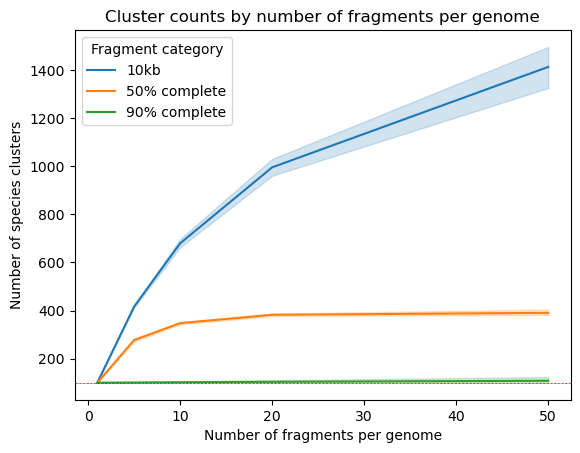

In [ ]:
### plot number of clusters vs number of fragments at each fragmentation level
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.lineplot(x='count', y='clusters', hue='Fragment category', hue_order=['10kb', '50% complete', '90% complete'], data=df)
ax.axhline(y=100, color='red', linestyle='--', linewidth=0.5)
plt.title('Cluster counts by number of fragments per genome')
plt.xlabel('Number of fragments per genome')
plt.ylabel('Number of species clusters')
plt.show()

# Takeaway: as the number of fragments per genome increases, the number of species clusters 
# also increases for fragmented genomes, indicating that fragmentation leads to overestimation of diversity.

In [5]:
print("10kb with 5 random fragments:", df[(df['Fragment category'] == '10kb') & (df['count'] == 5)]['clusters'].mean())
print("10kb with 50 random fragments:", df[(df['Fragment category'] == '10kb') & (df['count'] == 50)]['clusters'].mean())

print("50% with 5 random fragments:", df[(df['Fragment category'] == '50% complete') & (df['count'] == 5)]['clusters'].mean())
print("50% with 50 random fragments:", df[(df['Fragment category'] == '50% complete') & (df['count'] == 50)]['clusters'].mean())

print("90% with 5 random fragments:", df[(df['Fragment category'] == '90% complete') & (df['count'] == 5)]['clusters'].mean())
print("90% with 50 random fragments:", df[(df['Fragment category'] == '90% complete') & (df['count'] == 50)]['clusters'].mean())

10kb with 5 random fragments: 416.4
10kb with 50 random fragments: 1413.6
50% with 5 random fragments: 277.2
50% with 50 random fragments: 390.4
90% with 5 random fragments: 100.6
90% with 50 random fragments: 107.8
